# NEW SYSTEM

### Naming convention
|name|meaning|
|---|---|
|SingleState|photophysical state|
|PairedState|SingleStates of donor and acceptor combined|
|TransitionType|constant attributes of photophysical transition|
|Transition|constant and variable attributes of photophysical transition|
|combined states|combinations of SingleStates depending on number of fluorophores|
|combined state transition|transitions between combined states|
|realizable|theoretically possible|
|emission|fluorescent emission|
|event|detected fluorescent emission|
|resample|frame integration time|

In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.miscellaneous as mi
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc

import numpy as np

%load_ext autoreload
%autoreload 2

C:\Users\SagixOffice\miniconda3\envs\MarkovModels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


### Setup the fluorophores

In [2]:
object_1 = fl.Fluorophore(name='rhodamine', position=[1, 1])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[object_1])

array([[<AxesSubplot:xlabel='x [nm]', ylabel='y [nm]'>]], dtype=object)

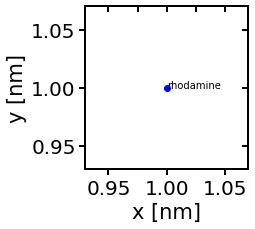

In [3]:
fluorophore_system.plot()

### Low excitation rate

In [4]:
excitation = tr.Transition(rate=1e11, transition_type=tr.TransitionType.EXCITATION)
emission = tr.Transition(rate=1e9, transition_type=tr.TransitionType.FLUORESCENT_EMISSION)
isc_st = tr.Transition(rate=1e8, transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_ST)
isc_ts = tr.Transition(rate=5e5, transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_TS)
hydroq = tr.Transition(rate=1e9, transition_type=tr.TransitionType.SINGLET_QUENCHING)
ics = tr.Transition(rate=1e9, transition_type=tr.TransitionType.INTERNAL_CONVERSION_S)

transitions = [excitation, emission, isc_st, isc_ts, hydroq, ics]

transition_set = tr.TransitionSet(transitions, fluorophore_system)

transition_set.finalize()

### Simulation

In [5]:
simulation = si.Simulation(transition_set)

simulation.run(size=int(1e7), end_time=None, seed=3, use_memmap=None)

analysis = st.Analysis(simulation)

analysis.state_occupations

array([2.93930043e-07, 3.06644197e-04, 9.99693062e-01])

### Emissions

In [6]:
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='5ms', emccd_gain=10, seed=100)

array([[<AxesSubplot:title={'center':'intensity distribution'}, xlabel='photon count', ylabel='PD'>]],
      dtype=object)

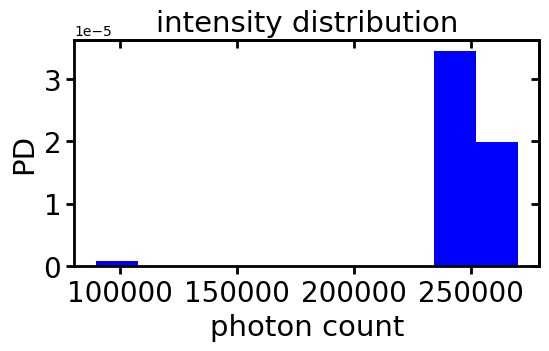

In [7]:
emissions.plot(mode='histogram')

array([[<AxesSubplot:title={'center':'fluorescence trajectory'}, xlabel='time [s]', ylabel='photon count'>]],
      dtype=object)

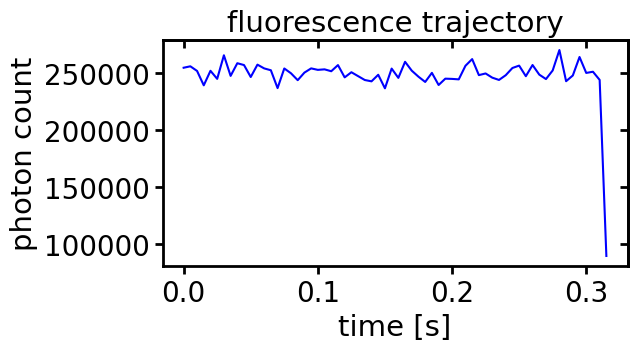

In [8]:
emissions.plot(mode='time_series')

In [9]:
excitation = tr.Transition(rate=1e11, transition_type=tr.TransitionType.EXCITATION)
emission = tr.Transition(rate=1e9, transition_type=tr.TransitionType.FLUORESCENT_EMISSION)
isc_st = tr.Transition(rate=1e8, transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_ST)
isc_ts = tr.Transition(rate=5e5, transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_TS)
hydroq = tr.Transition(rate=0, transition_type=tr.TransitionType.SINGLET_QUENCHING)
ics = tr.Transition(rate=1e9, transition_type=tr.TransitionType.INTERNAL_CONVERSION_S)

transitions = [excitation, emission, isc_st, isc_ts, hydroq, ics]

transition_set = tr.TransitionSet(transitions, fluorophore_system)

transition_set.finalize()

In [10]:
simulation = si.Simulation(transition_set)

simulation.run(size=int(1e7), end_time=None, seed=3, use_memmap=None)

analysis = st.Analysis(simulation)

analysis.state_occupations

array([1.35405887e-07, 3.10523145e-04, 9.99689341e-01])

In [11]:
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='5ms', emccd_gain=10, seed=100)

array([[<AxesSubplot:title={'center':'fluorescence trajectory'}, xlabel='time [s]', ylabel='photon count'>]],
      dtype=object)

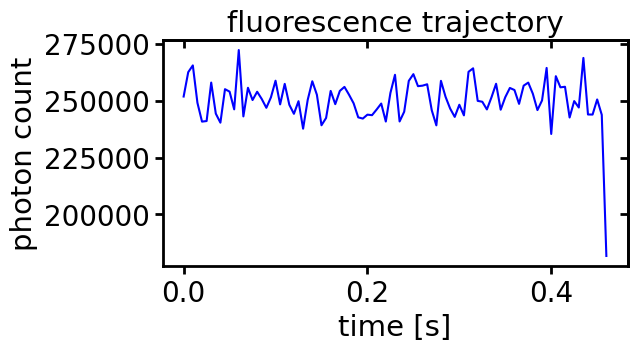

In [12]:
emissions.plot(mode='time_series')

In [13]:
emissions.event_time_series.mean()

250047.17204301077